# Machine Learning Classifier for Lung Disease

## Logistic Regression
Before using more of the much more complex models, we will first attempt to classify the models with Multinomial Logistic Regression. 

In [6]:
import os
import cv2
import numpy as np
from cv2 import ml
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import matplotlib.pyplot as plt
from tqdm import tqdm

First, we preprocess the data by loading in the dataset into an array, for this model we applied CLAHE, Contrast Limited Adaptive Histogram Equalization (CLAHE) is an advanced image processing technique that enhances local contrast by dividing images into small tiles and applying histogram equalization to each, rather than the whole image. This is ideal for the lung images to emphasize the details that would otherwise be overlooked. 

In [2]:
def load_lung_disease_dataset(base_path, img_size=(224, 224)):
    data = []
    labels = []
    
    if not os.path.exists(base_path):
        print(f"Error: Path {base_path} not found.")
        return None, None
        
    class_names = sorted([f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))])
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    for idx, label in enumerate(class_names):
        folder_path = os.path.join(base_path, label)
        files = os.listdir(folder_path)
        
        for img_name in tqdm(files, desc=f"Loading {label}", leave=False):
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                continue
            
            img = clahe.apply(img)
            img = cv2.resize(img, img_size)
            
            data.append(img.flatten() / 255.0)
            labels.append(idx)
            
    return np.array(data, dtype=np.float32), np.array(labels, dtype=np.int32)

### Load Data set

In [3]:
X, y = load_lung_disease_dataset('1/dataset_combined')

### Split Dataset
The data set is split three-Way (Train 70%, Val 15%, Test 15%) while ensuring that the split is stratified to avoid underrepresentation.

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full
)

y_train = y_train.reshape(-1, 1).astype(np.float32)
y_val = y_val.reshape(-1, 1).astype(np.float32)
y_test = y_test.reshape(-1, 1).astype(np.float32)

### Hyperparameter Tuning (Grid Search)
For this model, we identified mini batch sizes and learning rate as the hyperparameters. We will be tuning these to identify the "best model"

In [5]:
learning_rates = [0.1, 0.01, 0.001]

mini_batch_sizes = [32, 64, 128]
mb_sizes = tqdm(mini_batch_sizes)

total_iters = 500

best_val_acc = -1
best_params = {}
best_model = None

print(f"\nStarting Grid Search on {len(learning_rates) * len(mini_batch_sizes)} combinations")

for lr_val in learning_rates:
    for batch_size in mb_sizes:
        mb_sizes.set_description(f"Trying {lr_val} Learning Rate, {batch_size} Batch Size")
        
        model = ml.LogisticRegression_create()
        model.setTrainMethod(ml.LogisticRegression_MINI_BATCH)
        model.setMiniBatchSize(batch_size)
        model.setLearningRate(lr_val)
        model.setIterations(total_iters)
        
        model.train(X_train, ml.ROW_SAMPLE, y_train)
        
        _, y_val_pred = model.predict(X_val)
        val_accuracy = (np.sum(y_val_pred.flatten() == y_val.flatten()) / y_val.size) * 100
        
        print(f"Tested -> LR: {lr_val}, Batch: {batch_size} | Val Acc: {val_accuracy:.2f}%")
        
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            best_params = {'lr': lr_val, 'batch': batch_size}
            best_model = model

print(f"\nBest Parameters: {best_params} with {best_val_acc:.2f}% Validation Accuracy.")


Trying 0.1 Learning Rate, 32 Batch Size:   0%|          | 0/3 [00:00<?, ?it/s]


Starting Grid Search on 9 combinations


Trying 0.1 Learning Rate, 64 Batch Size:  33%|███▎      | 1/3 [03:41<07:21, 220.99s/it]

Tested -> LR: 0.1, Batch: 32 | Val Acc: 72.79%


Trying 0.1 Learning Rate, 128 Batch Size:  67%|██████▋   | 2/3 [08:51<04:33, 273.85s/it]

Tested -> LR: 0.1, Batch: 64 | Val Acc: 72.21%


Trying 0.1 Learning Rate, 128 Batch Size: 100%|██████████| 3/3 [14:02<00:00, 280.89s/it]

Tested -> LR: 0.1, Batch: 128 | Val Acc: 77.87%


Tested -> LR: 0.01, Batch: 32 | Val Acc: 75.76%
Tested -> LR: 0.01, Batch: 64 | Val Acc: 75.11%
Tested -> LR: 0.01, Batch: 128 | Val Acc: 72.93%
Tested -> LR: 0.001, Batch: 32 | Val Acc: 70.10%
Tested -> LR: 0.001, Batch: 64 | Val Acc: 67.71%
Tested -> LR: 0.001, Batch: 128 | Val Acc: 59.80%

Best Parameters: {'lr': 0.1, 'batch': 128} with 77.87% Validation Accuracy.


The Hyperparameter training determined that a learning rate of 0.1 and a batch size of 128 is the optimal hyperparameters for the Logistic Regression yielding an accuracy of 78%.

### Final Evaluation on Test Set



Evaluating best model on unseen Test Set...
Final Test Accuracy: 77.71%
              precision    recall  f1-score   support

         0.0       0.92      0.85      0.88       192
         1.0       0.86      0.94      0.90       491
         2.0       0.67      0.94      0.78       450
         3.0       0.75      0.11      0.19       249

    accuracy                           0.78      1382
   macro avg       0.80      0.71      0.69      1382
weighted avg       0.79      0.78      0.73      1382



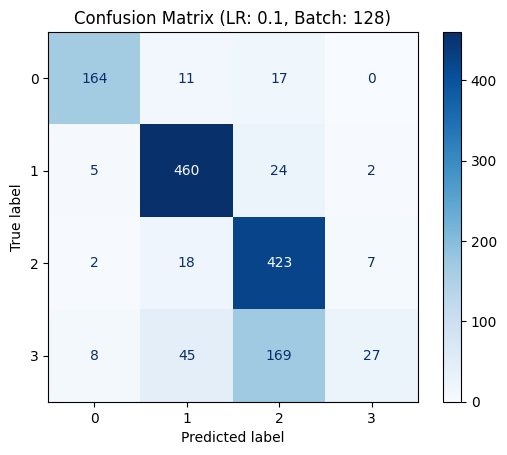

In [7]:
print("\nEvaluating best model on unseen Test Set...")
_, y_pred = best_model.predict(X_test)

final_accuracy = (np.sum(y_pred.flatten() == y_test.flatten()) / y_test.size) * 100
print(f'Final Test Accuracy: {final_accuracy:.2f}%')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (LR: {best_params['lr']}, Batch: {best_params['batch']})")
plt.show()

best_model.save("best_lung_disease_model.yml")

## Model Performance
As seen with the results, the model did surprisingly well on the test set with 77% accuracy, however, with the confusion matrix, we can see clearly where the model struggled. It appears that there is a difficulty to differentiate between the two pnuemonia classes which is understandable since they both represent the same disease.